# Homework_2 
Nombre: Dafne Andrea Mamani Vila

## PAso 1: Ver el diccionario de los datos

In [1]:
import requests

url = "https://codeforces.com/api/contest.list"
response = requests.get(url)
print(response.json())  # Devuelve un diccionario con los datos
#print(response)  # 200 --> Correcto 

{'status': 'OK', 'result': [{'id': 2101, 'name': 'Codeforces Round (Div. 1)', 'type': 'CF', 'phase': 'BEFORE', 'frozen': False, 'durationSeconds': 9000, 'startTimeSeconds': 1746974100, 'relativeTimeSeconds': -2132848}, {'id': 2102, 'name': 'Codeforces Round (Div. 2)', 'type': 'CF', 'phase': 'BEFORE', 'frozen': False, 'durationSeconds': 9000, 'startTimeSeconds': 1746974100, 'relativeTimeSeconds': -2132848}, {'id': 2099, 'name': 'Codeforces Round (Div. 1)', 'type': 'CF', 'phase': 'BEFORE', 'frozen': False, 'durationSeconds': 7200, 'startTimeSeconds': 1746261300, 'relativeTimeSeconds': -1420048}, {'id': 2100, 'name': 'Codeforces Round (Div. 2)', 'type': 'CF', 'phase': 'BEFORE', 'frozen': False, 'durationSeconds': 7200, 'startTimeSeconds': 1746261300, 'relativeTimeSeconds': -1420048}, {'id': 2104, 'name': 'Educational Codeforces Round 178 (Rated for Div. 2)', 'type': 'ICPC', 'phase': 'BEFORE', 'frozen': False, 'durationSeconds': 7200, 'startTimeSeconds': 1745850900, 'relativeTimeSeconds': 

## PAso 2: Código que se encarga de obtener y guardar datos relevantes de un concurso especifico de Codeforces (ID 2053)

In [5]:
import os
import requests
import pandas as pd
from datetime import datetime

# Crear carpeta para guardar archivos
CONTEST_ID = 2053
FOLDER = str(CONTEST_ID)
os.makedirs(FOLDER, exist_ok=True)

# Función auxiliar para hacer requests
def get_json(url):
    response = requests.get(url)
    data = response.json()
    if data['status'] != 'OK':
        raise Exception(f"Error al obtener datos desde: {url}")
    return data['result']

# 1. Obtener info del concurso y problemas
standings_url = f"https://codeforces.com/api/contest.standings?contestId={CONTEST_ID}&from=1&count=1000"
standings = get_json(standings_url)

# Guardar info del concurso
contest_info = {
    'id_concurso': standings['contest']['id'],
    'nombre_concurso': standings['contest']['name'],
    'hora_inicio_concurso': datetime.fromtimestamp(standings['contest']['startTimeSeconds'])
}
pd.DataFrame([contest_info]).to_csv(f"{FOLDER}/contest_info.csv", index=False)

# Guardar info de problemas
problems = standings['problems']
problems_data = []
for p in problems:
    problems_data.append({
        'problem_index': p['index'],
        'problem_name': p['name'],
        'rating': p.get('rating', None),
        'tags': ','.join(p.get('tags', []))
    })
pd.DataFrame(problems_data).to_csv(f"{FOLDER}/problems.csv", index=False)

# 2. Obtener lista de participantes activos (rated)
participants_url = "https://codeforces.com/api/user.ratedList?activeOnly=true"
participants = get_json(participants_url)
participants_df = pd.DataFrame(participants)
participants_df.to_csv(f"{FOLDER}/participants.csv", index=False)

# 3. Obtener submissions
submissions_url = f"https://codeforces.com/api/contest.status?contestId={CONTEST_ID}"
submissions = get_json(submissions_url)

submissions_data = []
for s in submissions:
    if 'author' in s and 'members' in s['author'] and s['author']['members']:
        submissions_data.append({
            'id_autor': s['author']['members'][0]['handle'],
            'problem_index': s['problem']['index'],
            'problem_name': s['problem']['name'],
            'verdict': s.get('verdict', 'UNKNOWN'),
            'runtime': s.get('timeConsumedMillis', None),
            'memory': s.get('memoryConsumedBytes', None),
            'language': s.get('programmingLanguage', None),
            'relative_time_seconds': s.get('relativeTimeSeconds', None),
            'timestamp': datetime.fromtimestamp(s['creationTimeSeconds']),
            'id_concurso': CONTEST_ID
        })
pd.DataFrame(submissions_data).to_csv(f"{FOLDER}/submissions.csv", index=False)

# 4. Obtener cambios de rating
rating_changes_url = f"https://codeforces.com/api/contest.ratingChanges?contestId={CONTEST_ID}"
rating_changes = get_json(rating_changes_url)
rating_df = pd.DataFrame(rating_changes)
rating_df.to_csv(f"{FOLDER}/rating_changes.csv", index=False)

print(f"✅ ¡Listo! Todos los archivos del concurso {CONTEST_ID} fueron guardados en la carpeta '{FOLDER}/'")


✅ ¡Listo! Todos los archivos del concurso 2053 fueron guardados en la carpeta '2053/'


## 

## Paso 3: Muestra los primeros registros de cada CSV del concurso 2053
(Este paso es importante por que me ayuda a enetender mejor el contenido de los datos de un concurso específico)

In [7]:
# Mostrar los primeros registros de cada CSV para revisión rápida
files = ['contest_info.csv', 'problems.csv', 'participants.csv', 'submissions.csv', 'rating_changes.csv']

for file in files:
    file_path = os.path.join(FOLDER, file)
    print(f"\nContenido de {file}:")
    df = pd.read_csv(file_path)
    print(df.head())  # Muestra las primeras filas del CSV para cada archivo



Contenido de contest_info.csv:
   id_concurso              nombre_concurso hora_inicio_concurso
0         2053  Good Bye 2024: 2025 is NEAR  2024-12-28 09:35:00

Contenido de problems.csv:
  problem_index                      problem_name  rating  \
0             A                  Tender Carpenter     800   
1             B         Outstanding Impressionist    1200   
2             C              Bewitching Stargazer    1500   
3             D        Refined Product Optimality    1700   
4             E  Resourceful Caterpillar Sequence    1900   

                                                tags  
0                            dp,geometry,greedy,math  
1   binary search,brute force,data structures,greedy  
2                bitmasks,divide and conquer,dp,math  
3  binary search,data structures,greedy,math,sche...  
4       dfs and similar,dp,games,graphs,greedy,trees  

Contenido de participants.csv:
      lastName        country  lastOnlineTimeSeconds       city  rating  \
0     

## Paso 4: Crear una lista de los concursos que se dieron entre JUL - DIC 2024
nombre de la lista: "concursos_filtrados"

In [19]:
import requests
import json
from datetime import datetime

# Paso 1: Obtener todos los concursos
contests_url = "https://codeforces.com/api/contest.list"
response = requests.get(contests_url).json()

# Paso 2: Filtrar concursos
keywords = ["Hello", "Round", "Good Bye"]
concursos_filtrados = []

for contest in response['result']:
    if contest['phase'] == 'FINISHED':
        start = datetime.utcfromtimestamp(contest['startTimeSeconds'])
        if start.year == 2024 and 7 <= start.month <= 12:
            if any(k in contest['name'] for k in keywords):
                concursos_filtrados.append({
                    'id': contest['id'],
                    'nombre': contest['name'],
                    'fecha': start.strftime('%Y-%m-%d')
                })

# Guardar como JSON
with open("concursos_filtrados.json", "w", encoding="utf-8") as f:
    json.dump(concursos_filtrados, f, ensure_ascii=False, indent=2)

print(f"✅ Lista guardada en concursos_filtrados.json ({len(concursos_filtrados)} concursos)")


✅ Lista guardada en concursos_filtrados.json (57 concursos)


C:\Users\usuario\AppData\Local\Temp\ipykernel_4808\3018073369.py:15: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  start = datetime.utcfromtimestamp(contest['startTimeSeconds'])


## Paso 5: Mostrar el ID, el nombre y la fecha de los concursos dentro de la lista

In [21]:
# Paso 3: Mostrar resultados
print(f"🔍 Concursos filtrados: {len(concursos_filtrados)}\n")

for c in concursos_filtrados:
    print(f"🆔 {c['id']} | {c['nombre']} | {c['fecha']}")

🔍 Concursos filtrados: 57

🆔 2053 | Good Bye 2024: 2025 is NEAR | 2024-12-28
🆔 2043 | Educational Codeforces Round 173 (Rated for Div. 2) | 2024-12-24
🆔 2051 | Codeforces Round 995 (Div. 3) | 2024-12-22
🆔 2049 | Codeforces Round 994 (Div. 2) | 2024-12-20
🆔 2048 | Codeforces Global Round 28 | 2024-12-19
🆔 2044 | Codeforces Round 993 (Div. 4) | 2024-12-15
🆔 2040 | Codeforces Round 992 (Div. 2) | 2024-12-08
🆔 2050 | Codeforces Round 991 (Div. 3) | 2024-12-05
🆔 2046 | Codeforces Round 990 (Div. 1) | 2024-12-03
🆔 2047 | Codeforces Round 990 (Div. 2) | 2024-12-03
🆔 2042 | Educational Codeforces Round 172 (Rated for Div. 2) | 2024-12-02
🆔 2034 | Rayan Programming Contest 2024 - Selection (Codeforces Round 989, Div. 1 + Div. 2) | 2024-11-30
🆔 2039 | CodeTON Round 9 (Div. 1 + Div. 2, Rated, Prizes!) | 2024-11-23
🆔 2037 | Codeforces Round 988 (Div. 3) | 2024-11-17
🆔 2031 | Codeforces Round 987 (Div. 2) | 2024-11-15
🆔 2028 | Codeforces Round 986 (Div. 2) | 2024-11-10
🆔 2029 | Refact.ai Match 1 (C

## Paso 6: Crear el data frame con todos los CVS juntos creados en el PASO 2

In [14]:
import os
import requests
import pandas as pd
from datetime import datetime

# Crear carpeta para guardar archivos
CONTEST_ID = 2053
FOLDER = str(CONTEST_ID)
os.makedirs(FOLDER, exist_ok=True)

# Función auxiliar para hacer requests
def get_json(url):
    response = requests.get(url)
    data = response.json()
    if data['status'] != 'OK':
        raise Exception(f"Error al obtener datos desde: {url}")
    return data['result']

# 1. Obtener info del concurso y problemas
standings_url = f"https://codeforces.com/api/contest.standings?contestId={CONTEST_ID}&from=1&count=1000"
standings = get_json(standings_url)

# Información del concurso
contest_info = {
    'id_concurso': standings['contest']['id'],
    'nombre_concurso': standings['contest']['name'],
    'hora_inicio_concurso': datetime.fromtimestamp(standings['contest']['startTimeSeconds'])
}

# Obtener problemas
problems = standings['problems']
problems_data = []
for p in problems:
    problems_data.append({
        'problem_index': p['index'],
        'problem_name': p['name'],
        'rating': p.get('rating', None),
        'tags': ','.join(p.get('tags', []))
    })

# 2. Obtener lista de participantes activos (rated)
participants_url = "https://codeforces.com/api/user.ratedList?activeOnly=true"
participants = get_json(participants_url)

# 3. Obtener submissions
submissions_url = f"https://codeforces.com/api/contest.status?contestId={CONTEST_ID}"
submissions = get_json(submissions_url)

# Inicializamos una lista para almacenar todos los datos
all_data = []

# Para cada envío (submission), vamos a añadir la información relevante
for s in submissions:
    if 'author' in s and 'members' in s['author'] and s['author']['members']:
        submission_data = {
            'id_autor': s['author']['members'][0]['handle'],
            'problem_index': s['problem']['index'],
            'problem_name': s['problem']['name'],
            'verdict': s.get('verdict', 'UNKNOWN'),
            'runtime': s.get('timeConsumedMillis', None),
            'memory': s.get('memoryConsumedBytes', None),
            'language': s.get('programmingLanguage', None),
            'relative_time_seconds': s.get('relativeTimeSeconds', None),
            'timestamp': datetime.fromtimestamp(s['creationTimeSeconds']),
            'id_concurso': CONTEST_ID,
            'nombre_concurso': contest_info['nombre_concurso'],
            'hora_inicio_concurso': contest_info['hora_inicio_concurso']
        }
        all_data.append(submission_data)

# Convertimos todo a un DataFrame
df = pd.DataFrame(all_data)

# Para obtener un resumen de los participantes y su información de rating
rating_changes_url = f"https://codeforces.com/api/contest.ratingChanges?contestId={CONTEST_ID}"
rating_changes = get_json(rating_changes_url)
rating_changes_data = []
for change in rating_changes:
    rating_changes_data.append({
        'id_autor': change['handle'],
        'old_rating': change['oldRating'],
        'new_rating': change['newRating'],
        'rating_change': change['newRating'] - change['oldRating'],
        'id_concurso': CONTEST_ID
    })

# Crear DataFrame con los cambios de rating
rating_df = pd.DataFrame(rating_changes_data)

# Agregar la información de rating al DataFrame de submissions
df = pd.merge(df, rating_df, on=['id_autor', 'id_concurso'], how='left')

# Guardar todo en un único CSV
df.to_csv(f"{FOLDER}/concurso_2053_data.csv", index=False)

print(f"✅ ¡Listo! El DataFrame con toda la información se guardó en '{FOLDER}/concurso_2053_data.csv'")


✅ ¡Listo! El DataFrame con toda la información se guardó en '2053/concurso_2053_data.csv'


## Paso 7: Mostrar las primeras filas del CSV dónde estan todos los datos del concurso 2053

In [16]:
# Mostrar las primeras filas del CSV para revisión rápida
df_vista = pd.read_csv(f"{FOLDER}/concurso_2053_data.csv")
print("\n📋 Primeros registros del dataset combinado:")
print(df_vista.head())



📋 Primeros registros del dataset combinado:
            id_autor problem_index               problem_name  \
0              shvec             A           Tender Carpenter   
1          squarenix             A           Tender Carpenter   
2  tripathivinayak29             B  Outstanding Impressionist   
3  tripathivinayak29             B  Outstanding Impressionist   
4  tripathivinayak29             B  Outstanding Impressionist   

               verdict  runtime    memory                  language  \
0                   OK       46    102400  C++23 (GCC 14-64, msys2)   
1                   OK       46         0  C++23 (GCC 14-64, msys2)   
2                   OK      452   3174400          C++17 (GCC 7-32)   
3         WRONG_ANSWER       61  12288000          C++17 (GCC 7-32)   
4  TIME_LIMIT_EXCEEDED     1000    102400          C++17 (GCC 7-32)   

   relative_time_seconds            timestamp  id_concurso  \
0             2147483647  2025-04-16 15:40:23         2053   
1            

## Paso 8: Generalizar el codigo para la lista de concursos del paso 4

In [23]:
import os
import json
import requests
import pandas as pd
from datetime import datetime

# Leer concursos desde JSON
with open("concursos_filtrados.json", "r", encoding="utf-8") as f:
    concursos_filtrados = json.load(f)

# Función para hacer requests
def get_json(url):
    response = requests.get(url)
    data = response.json()
    if data['status'] != 'OK':
        raise Exception(f"Error al obtener datos desde: {url}")
    return data['result']

# Obtener lista de participantes activos (una sola vez)
participants_url = "https://codeforces.com/api/user.ratedList?activeOnly=true"
participants = get_json(participants_url)

# Procesar cada concurso
for concurso in concursos_filtrados:
    CONTEST_ID = concurso['id']
    print(f"⏳ Procesando concurso {CONTEST_ID}...")

    # Crear carpeta
    FOLDER = str(CONTEST_ID)
    os.makedirs(FOLDER, exist_ok=True)

    # Obtener standings
    standings_url = f"https://codeforces.com/api/contest.standings?contestId={CONTEST_ID}&from=1&count=1000"
    standings = get_json(standings_url)

    # Info del concurso
    contest_info = {
        'id_concurso': standings['contest']['id'],
        'nombre_concurso': standings['contest']['name'],
        'hora_inicio_concurso': datetime.fromtimestamp(standings['contest']['startTimeSeconds'])
    }

    # Problemas
    problems = standings['problems']
    problems_data = []
    for p in problems:
        problems_data.append({
            'problem_index': p['index'],
            'problem_name': p['name'],
            'rating': p.get('rating', None),
            'tags': ','.join(p.get('tags', []))
        })

    # Submissions
    submissions_url = f"https://codeforces.com/api/contest.status?contestId={CONTEST_ID}"
    submissions = get_json(submissions_url)

    all_data = []
    for s in submissions:
        if 'author' in s and 'members' in s['author'] and s['author']['members']:
            submission_data = {
                'id_autor': s['author']['members'][0]['handle'],
                'problem_index': s['problem']['index'],
                'problem_name': s['problem']['name'],
                'verdict': s.get('verdict', 'UNKNOWN'),
                'runtime': s.get('timeConsumedMillis', None),
                'memory': s.get('memoryConsumedBytes', None),
                'language': s.get('programmingLanguage', None),
                'relative_time_seconds': s.get('relativeTimeSeconds', None),
                'timestamp': datetime.fromtimestamp(s['creationTimeSeconds']),
                'id_concurso': CONTEST_ID,
                'nombre_concurso': contest_info['nombre_concurso'],
                'hora_inicio_concurso': contest_info['hora_inicio_concurso']
            }
            all_data.append(submission_data)

    df = pd.DataFrame(all_data)

    # Cambios de rating
    rating_changes_url = f"https://codeforces.com/api/contest.ratingChanges?contestId={CONTEST_ID}"
    try:
        rating_changes = get_json(rating_changes_url)
        rating_changes_data = []
        for change in rating_changes:
            rating_changes_data.append({
                'id_autor': change['handle'],
                'old_rating': change['oldRating'],
                'new_rating': change['newRating'],
                'rating_change': change['newRating'] - change['oldRating'],
                'id_concurso': CONTEST_ID
            })
        rating_df = pd.DataFrame(rating_changes_data)
        df = pd.merge(df, rating_df, on=['id_autor', 'id_concurso'], how='left')
    except Exception as e:
        print(f"⚠️ Sin rating changes para {CONTEST_ID}: {e}")
        df['old_rating'] = None
        df['new_rating'] = None
        df['rating_change'] = None

    # Guardar archivo
    output_path = f"{FOLDER}/concurso_{CONTEST_ID}_data.csv"
    df.to_csv(output_path, index=False)
    print(f"✅ Guardado: {output_path}")



⏳ Procesando concurso 2053...
✅ Guardado: 2053/concurso_2053_data.csv
⏳ Procesando concurso 2043...
✅ Guardado: 2043/concurso_2043_data.csv
⏳ Procesando concurso 2051...
✅ Guardado: 2051/concurso_2051_data.csv
⏳ Procesando concurso 2049...
✅ Guardado: 2049/concurso_2049_data.csv
⏳ Procesando concurso 2048...
✅ Guardado: 2048/concurso_2048_data.csv
⏳ Procesando concurso 2044...
✅ Guardado: 2044/concurso_2044_data.csv
⏳ Procesando concurso 2040...
✅ Guardado: 2040/concurso_2040_data.csv
⏳ Procesando concurso 2050...
✅ Guardado: 2050/concurso_2050_data.csv
⏳ Procesando concurso 2046...
✅ Guardado: 2046/concurso_2046_data.csv
⏳ Procesando concurso 2047...
✅ Guardado: 2047/concurso_2047_data.csv
⏳ Procesando concurso 2042...
✅ Guardado: 2042/concurso_2042_data.csv
⏳ Procesando concurso 2034...
✅ Guardado: 2034/concurso_2034_data.csv
⏳ Procesando concurso 2039...
✅ Guardado: 2039/concurso_2039_data.csv
⏳ Procesando concurso 2037...
✅ Guardado: 2037/concurso_2037_data.csv
⏳ Procesando concurs

## Paso 9: Guardar los cvs de cada concurso y crear un archivo que agrupe todos los cvs de todos los concursos

In [25]:
import os
import pandas as pd

# Ruta donde están guardadas las carpetas con los archivos CSV
base_folder = "."  # o reemplaza por la ruta si están en otra carpeta

# Lista para almacenar todos los DataFrames
dataframes = []

# Recorremos cada carpeta (una por cada concurso)
for folder_name in os.listdir(base_folder):
    folder_path = os.path.join(base_folder, folder_name)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.startswith("concurso_") and file.endswith("_data.csv"):
                csv_path = os.path.join(folder_path, file)
                print(f"📂 Leyendo: {csv_path}")
                df = pd.read_csv(csv_path, parse_dates=['timestamp', 'hora_inicio_concurso'])
                dataframes.append(df)

# Unimos todos los DataFrames en uno solo
df_total = pd.concat(dataframes, ignore_index=True)

# Guardamos el resultado si se desea
df_total.to_csv("todos_los_concursos.csv", index=False)
print("✅ Archivo combinado guardado como 'todos_los_concursos.csv'")


📂 Leyendo: .\1983\concurso_1983_data.csv
📂 Leyendo: .\1988\concurso_1988_data.csv
📂 Leyendo: .\1990\concurso_1990_data.csv
📂 Leyendo: .\1991\concurso_1991_data.csv
📂 Leyendo: .\1992\concurso_1992_data.csv
📂 Leyendo: .\1993\concurso_1993_data.csv
📂 Leyendo: .\1994\concurso_1994_data.csv
📂 Leyendo: .\1995\concurso_1995_data.csv
📂 Leyendo: .\1996\concurso_1996_data.csv
📂 Leyendo: .\1997\concurso_1997_data.csv
📂 Leyendo: .\1998\concurso_1998_data.csv
📂 Leyendo: .\1999\concurso_1999_data.csv
📂 Leyendo: .\2000\concurso_2000_data.csv
📂 Leyendo: .\2001\concurso_2001_data.csv
📂 Leyendo: .\2002\concurso_2002_data.csv
📂 Leyendo: .\2003\concurso_2003_data.csv
📂 Leyendo: .\2004\concurso_2004_data.csv
📂 Leyendo: .\2005\concurso_2005_data.csv
📂 Leyendo: .\2006\concurso_2006_data.csv
📂 Leyendo: .\2007\concurso_2007_data.csv
📂 Leyendo: .\2008\concurso_2008_data.csv
📂 Leyendo: .\2009\concurso_2009_data.csv
📂 Leyendo: .\2010\concurso_2010_data.csv
📂 Leyendo: .\2013\concurso_2013_data.csv
📂 Leyendo: .\201

## Paso 10: Mostrar el data frame de "todos_los_concursos.csv"

In [27]:
df_total


,id_autor,problem_index,problem_name,verdict,runtime,memory,language,relative_time_seconds,timestamp,id_concurso,nombre_concurso,hora_inicio_concurso,old_rating,new_rating,rating_change
0,utsav_07,A,Array Divisibility,OK,46,0,C++20 (GCC 13-64),2147483647,2025-04-16 13:10:13,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
1,h233cd-08,A,Array Divisibility,OK,62,0,C++17 (GCC 7-32),2147483647,2025-04-16 13:00:45,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
2,AMRGhayth,A,Array Divisibility,OK,31,0,C++20 (GCC 13-64),2147483647,2025-04-16 12:37:29,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
3,GJLH5,A,Array Divisibility,OK,46,819200,C++17 (GCC 7-32),2147483647,2025-04-16 12:09:40,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
4,chenq,D,Swap Dilemma,RUNTIME_ERROR,30,0,"C++23 (GCC 14-64, msys2)",2147483647,2025-04-16 09:41:20,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10490643,A_G,A,Tender Carpenter,WRONG_ANSWER,46,0,C++20 (GCC 13-64),67,2024-12-28 09:36:07,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,3059.0,3040.0,-19.0
10490644,donshaaab,A,Tender Carpenter,SKIPPED,15,0,"C++23 (GCC 14-64, msys2)",64,2024-12-28 09:36:04,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,359.0,583.0,224.0
10490645,jsmes_arther,A,Tender Carpenter,SKIPPED,0,0,GNU C11,61,2024-12-28 09:36:01,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,944.0,845.0,-99.0
10490646,petrov.matvii,A,Tender Carpenter,WRONG_ANSWER,31,0,C++17 (GCC 7-32),61,2024-12-28 09:36:01,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,954.0,914.0,-40.0


## Paso 11: Descripción del Conjunto de Datos

### 🔗 Puntos finales de la API utilizados

Se utilizaron los siguientes endpoints de la API de Codeforces:

- `https://codeforces.com/api/contest.list`: Lista de todos los concursos.
- `https://codeforces.com/api/contest.standings`: Información de posiciones y problemas de cada concurso.
- `https://codeforces.com/api/contest.status`: Submissions individuales realizadas por los usuarios en cada concurso.
- `https://codeforces.com/api/contest.ratingChanges`: Cambios de rating por usuario en cada concurso.
- `https://codeforces.com/api/user.ratedList?activeOnly=true`: Lista de usuarios activos con rating.

### 📁 Estructura del conjunto de datos

El conjunto de datos final (`df_total`) es una combinación de múltiples archivos `.csv` generados por concurso, y contiene información detallada de cada submission, unida a la metadata del concurso y a los cambios de rating del usuario (si están disponibles).

Cada fila del DataFrame representa una submission realizada por un usuario en un concurso.

### 📌 Descripción de variables

- **id_autor**: Handle (nombre de usuario) del participante que hizo la submission.
- **problem_index**: Índice del problema (ej. A, B, C...).
- **problem_name**: Nombre del problema.
- **verdict**: Resultado de la submission (ej. OK, WRONG_ANSWER, TIME_LIMIT_EXCEEDED).
- **runtime**: Tiempo que tomó la ejecución en milisegundos.
- **memory**: Memoria consumida en bytes.
- **language**: Lenguaje de programación utilizado.
- **relative_time_seconds**: Tiempo transcurrido desde el inicio del concurso hasta la submission (en segundos).
- **timestamp**: Fecha y hora exacta en la que se realizó la submission.
- **id_concurso**: ID único del concurso.
- **nombre_concurso**: Nombre completo del concurso.
- **hora_inicio_concurso**: Fecha y hora de inicio del concurso.
- **old_rating**: Rating del usuario antes del concurso.
- **new_rating**: Rating del usuario después del concurso.
- **rating_change**: Variación en el rating del usuario después del concurso.

Este conjunto permite estudiar tanto el rendimiento individual de los usuarios como la dificultad relativa de los problemas, el volumen de actividad por concurso, y el impacto en los ratings.



## Paso 12: verificar que los datos esten dentro del rango de tiempo jul-dic 2025

In [30]:
# Asegurar que la columna 'timestamp' esté en formato datetime
df_total['timestamp'] = pd.to_datetime(df_total['timestamp'], errors='coerce')

# Definir las fechas de corte
fecha_inicio = pd.Timestamp("2024-07-01")
fecha_fin = pd.Timestamp("2024-12-31 23:59:59")

# Filtrar por submissions entre julio y diciembre de 2024
df_filtrado = df_total[(df_total['timestamp'] >= fecha_inicio) & (df_total['timestamp'] <= fecha_fin)]

# Ver cuántas filas quedaron
print(f"✅ Filtrado realizado: {df_filtrado.shape[0]} submissions entre julio y diciembre 2024.")



✅ Filtrado realizado: 9428017 submissions entre julio y diciembre 2024.


In [32]:
df_total

,id_autor,problem_index,problem_name,verdict,runtime,memory,language,relative_time_seconds,timestamp,id_concurso,nombre_concurso,hora_inicio_concurso,old_rating,new_rating,rating_change
0,utsav_07,A,Array Divisibility,OK,46,0,C++20 (GCC 13-64),2147483647,2025-04-16 13:10:13,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
1,h233cd-08,A,Array Divisibility,OK,62,0,C++17 (GCC 7-32),2147483647,2025-04-16 13:00:45,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
2,AMRGhayth,A,Array Divisibility,OK,31,0,C++20 (GCC 13-64),2147483647,2025-04-16 12:37:29,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
3,GJLH5,A,Array Divisibility,OK,46,819200,C++17 (GCC 7-32),2147483647,2025-04-16 12:09:40,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
4,chenq,D,Swap Dilemma,RUNTIME_ERROR,30,0,"C++23 (GCC 14-64, msys2)",2147483647,2025-04-16 09:41:20,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,2024-07-07 09:35:00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10490643,A_G,A,Tender Carpenter,WRONG_ANSWER,46,0,C++20 (GCC 13-64),67,2024-12-28 09:36:07,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,3059.0,3040.0,-19.0
10490644,donshaaab,A,Tender Carpenter,SKIPPED,15,0,"C++23 (GCC 14-64, msys2)",64,2024-12-28 09:36:04,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,359.0,583.0,224.0
10490645,jsmes_arther,A,Tender Carpenter,SKIPPED,0,0,GNU C11,61,2024-12-28 09:36:01,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,944.0,845.0,-99.0
10490646,petrov.matvii,A,Tender Carpenter,WRONG_ANSWER,31,0,C++17 (GCC 7-32),61,2024-12-28 09:36:01,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 09:35:00,954.0,914.0,-40.0


## Paso 13: Observar la estructura general del dataframe y las estadisticas básicas

In [35]:
# Estructura general del DataFrame
df_total.info()

# Primeras filas (para ver estructura real)
df_total.head()

# Estadísticas básicas
df_total.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10490648 entries, 0 to 10490647
Data columns (total 15 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id_autor               object        
 1   problem_index          object        
 2   problem_name           object        
 3   verdict                object        
 4   runtime                int64         
 5   memory                 int64         
 6   language               object        
 7   relative_time_seconds  int64         
 8   timestamp              datetime64[ns]
 9   id_concurso            int64         
 10  nombre_concurso        object        
 11  hora_inicio_concurso   datetime64[ns]
 12  old_rating             float64       
 13  new_rating             float64       
 14  rating_change          float64       
dtypes: datetime64[ns](2), float64(3), int64(4), object(6)
memory usage: 1.2+ GB


,id_autor,problem_index,problem_name,verdict,runtime,memory,language,relative_time_seconds,timestamp,id_concurso,nombre_concurso,hora_inicio_concurso,old_rating,new_rating,rating_change
count,10490619,10490648,10490648,10490648,1.049065e+07,1.049065e+07,10490648,1.049065e+07,10490648,1.049065e+07,10490648,10490648,5.397979e+06,5.397979e+06,5.397979e+06
unique,272296,28,399,12,NaN,NaN,32,NaN,NaN,NaN,57,NaN,NaN,NaN,NaN
top,bkifhr8,B,Card Game,OK,NaN,NaN,C++17 (GCC 7-32),NaN,NaN,NaN,Codeforces Round 964 (Div. 4),NaN,NaN,NaN,NaN
freq,4163,2603348,140205,4708313,NaN,NaN,4158269,NaN,NaN,NaN,520868,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,3.006935e+02,8.660189e+06,NaN,1.059979e+09,2024-10-16 03:45:22.622077952,2.017175e+03,NaN,2024-09-26 17:36:10.734262784,1.126092e+03,1.187137e+03,6.104565e+01
min,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,4.000000e+00,2024-07-07 09:35:32,1.983000e+03,NaN,2024-07-07 09:35:00,-4.900000e+01,-5.000000e+01,-3.360000e+02
25%,NaN,NaN,NaN,NaN,4.600000e+01,0.000000e+00,NaN,2.650000e+03,2024-08-18 03:36:35,1.999000e+03,NaN,2024-08-10 09:35:00,8.820000e+02,9.240000e+02,-2.200000e+01
50%,NaN,NaN,NaN,NaN,7.700000e+01,0.000000e+00,NaN,8.999000e+03,2024-10-14 11:25:59,2.014000e+03,NaN,2024-09-21 09:45:00,1.155000e+03,1.173000e+03,2.500000e+01
75%,NaN,NaN,NaN,NaN,2.020000e+02,8.192000e+05,NaN,2.147484e+09,2024-12-05 10:30:48,2.034000e+03,NaN,2024-11-10 10:35:00,1.421000e+03,1.433000e+03,9.400000e+01
max,NaN,NaN,NaN,NaN,1.300000e+04,1.073766e+09,NaN,2.147484e+09,2025-04-16 18:40:57,2.053000e+03,NaN,2024-12-28 09:35:00,4.009000e+03,4.009000e+03,1.016000e+03


## Paso 14: Limpiar el dataframe y crear derivadas

In [38]:
# Copia del DataFrame original para trabajar sin modificarlo
df = df_total.copy()

# 🔹 FILTRO DE FECHAS entre julio y diciembre de 2024
df = df[(df['timestamp'] >= '2024-07-01') & (df['timestamp'] <= '2024-12-31')]

# 🔹 CREAR VARIABLES DERIVADAS

# Tiempo de respuesta en minutos desde inicio del concurso
df['time_to_answer'] = df['relative_time_seconds'] / 60

# Hora del día en que se hizo la submission (0-23)
df['hora_submission'] = df['timestamp'].dt.hour

# Rating alcanzado después de la submission
df['rating_achieved'] = df['old_rating'] + df['rating_change']

# 🔹 DATOS PARA GRÁFICO DE DENSIDAD: máximo rating por usuario
df_ratings = df[['id_autor', 'new_rating']].dropna()
max_rating_por_usuario = (
    df_ratings
    .groupby('id_autor')['new_rating']
    .max()
    .reset_index()
    .rename(columns={'new_rating': 'max_rating'})
)

# 🔹 FILTRO PARA ANÁLISIS CON RATING
df_rating_clean = df.dropna(subset=['old_rating', 'new_rating', 'rating_change'])

print("✅ Limpieza y transformación completadas")
print(f"Registros después del filtro temporal: {len(df)}")
print(f"Registros con rating válido: {len(df_rating_clean)}")



✅ Limpieza y transformación completadas
Registros después del filtro temporal: 9409962
Registros con rating válido: 5326521


## Paso 15: Volver a observar la estructura general del dataframe y las estadisticas básicas

In [55]:
print(df.head())  # Muestra las primeras filas del DataFrame para ver cómo se ve
print(df.describe())  # Estadísticas básicas para las columnas numéricas
print(df.info())  # Información general del DataFrame, incluyendo los tipos de datos


               id_autor problem_index        problem_name verdict  runtime  \
7387           yoonsica             B        Corner Twist      OK      140   
7388      ninjastyle339             A  Array Divisibility      OK       46   
7389            manavp8             A  Array Divisibility      OK       46   
7390  SarthakDenuMaster             E        I Love Balls      OK      514   
7391  SarthakDenuMaster             D        Swap Dilemma      OK      358   

       memory                  language  relative_time_seconds  \
7387  9420800                 PyPy 3-64             2147483647   
7388   102400          C++17 (GCC 7-32)             2147483647   
7389        0  C++23 (GCC 14-64, msys2)             2147483647   
7390   102400          C++17 (GCC 7-32)             2147483647   
7391   204800          C++17 (GCC 7-32)             2147483647   

               timestamp  id_concurso  \
7387 2024-12-30 21:16:33         1983   
7388 2024-12-30 16:33:35         1983   
7389 2024-1

## Paso 16: Graficos e Interpretaciones

## 1. Histograma de los tiempos de submission (time_to_answer)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de los tiempos de respuesta (time_to_answer)
plt.figure(figsize=(10,6))
sns.histplot(df['time_to_answer'], kde=True, bins=50, color='skyblue')
plt.title('Distribución de tiempos de respuesta (minutos)', fontsize=16)
plt.xlabel('Tiempo de respuesta (minutos)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(True)
plt.show()

C:\Users\usuario\AppData\Local\Temp\ipykernel_4808\1013920785.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='time_range', palette='viridis')


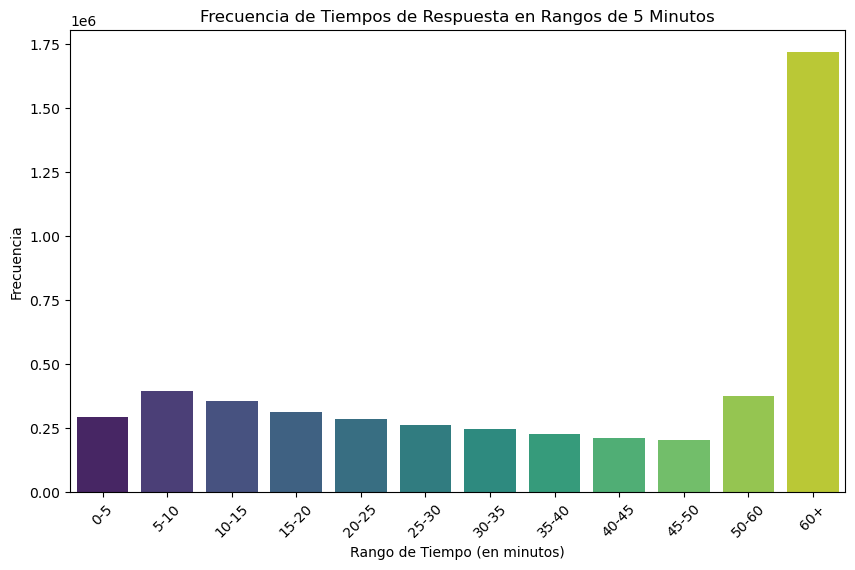

In [58]:
# Crear bins para agrupar los tiempos de respuesta
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 120]  # Puedes ajustar estos valores
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-60', '60+']
df['time_range'] = pd.cut(df['time_to_answer'], bins=bins, labels=labels, right=False)

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='time_range', palette='viridis')
plt.title("Frecuencia de Tiempos de Respuesta en Rangos de 5 Minutos")
plt.xlabel("Rango de Tiempo (en minutos)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()


INTERPRETACION: Con mayor frecuencia los participantes de los concursos se demoran mas 60 min en resolver los problemas.


## 2. Figura de densidad (Kernel Density Estimation) para el máximo rating de los usuarios

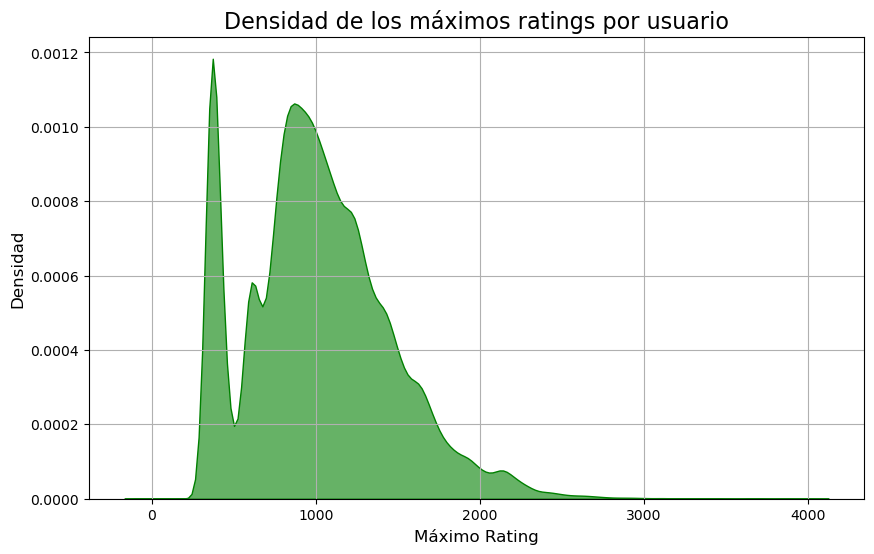

In [47]:
# Densidad del máximo rating alcanzado por cada usuario
plt.figure(figsize=(10,6))
sns.kdeplot(max_rating_por_usuario['max_rating'], fill=True, color='green', alpha=0.6)
plt.title('Densidad de los máximos ratings por usuario', fontsize=16)
plt.xlabel('Máximo Rating', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.grid(True)
plt.show()


INterpretacion: La figura de densidad (KDE) del máximo rating alcanzado por los usuarios revela una distribución bimodal, es decir, con dos picos marcados. El primer pico, alto y delgado, se concentra aproximandamente entre los valores 250 a 500, lo que indica que una gran proporción de usuarios tienen un rendimiento bajo o son posiblemente usuarios nuevos o inactivos. El segundo pico, más ancho , se extiende aproximadamente desde los 300 hasta los 2500 lo cual representa a un grupo más diverso de usuarios con un desempeño más alto o mayor participación. Es decir, probablemte halla dos grupos uyno de baja actividad o experiencia, y otro más activo o competente.

## 3. Boxplot de language vs time_to_answer

C:\Users\usuario\AppData\Local\Temp\ipykernel_4808\4029259486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='language', y='time_to_answer', data=df, palette='Set2')


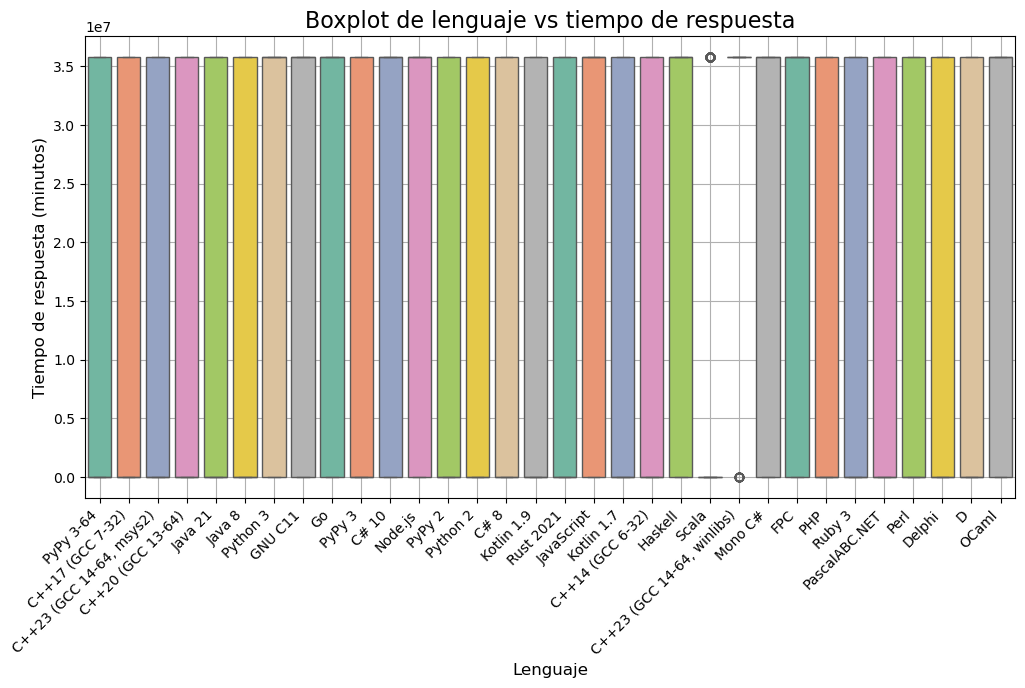

In [48]:
# Boxplot de lenguaje vs tiempo de respuesta
plt.figure(figsize=(12,6))
sns.boxplot(x='language', y='time_to_answer', data=df, palette='Set2')
plt.title('Boxplot de lenguaje vs tiempo de respuesta', fontsize=16)
plt.xlabel('Lenguaje', fontsize=12)
plt.ylabel('Tiempo de respuesta (minutos)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()


INterpretacion: La gran mayoria de de boxplots tienen cajas similares entre 0.0 y 3.5 ya que la gran mayoría de los tiempos de respuesta están dentro de ese rango.Esto significa que, en general, todos los lenguajes tienen tiempos de respuesta rápidos, inferiores a 3.5 minutos.Excepto para el lenguaje Scala y C++23 .

## 4. Binscatter de rating vs time_to_answer

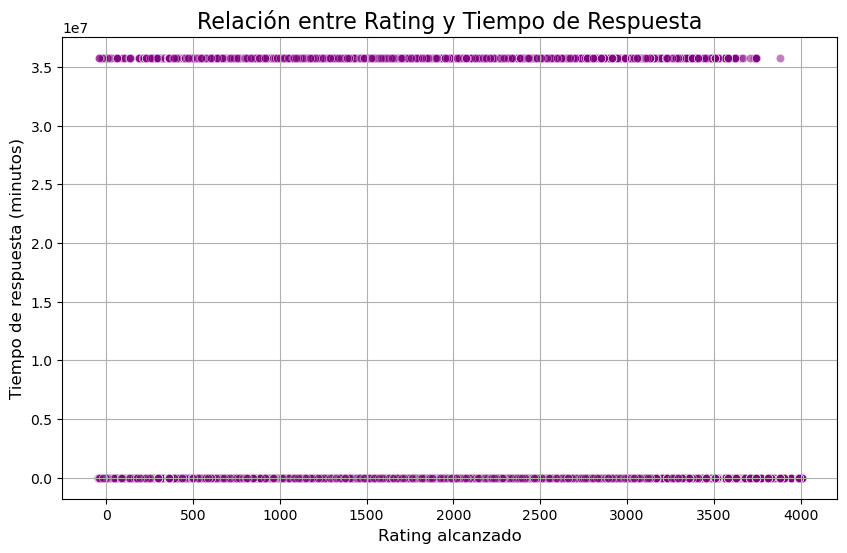

In [50]:
# Binscatter de rating vs tiempo de respuesta
plt.figure(figsize=(10,6))
sns.scatterplot(x='rating_achieved', y='time_to_answer', data=df_rating_clean, color='purple', alpha=0.5)
plt.title('Relación entre Rating y Tiempo de Respuesta', fontsize=16)
plt.xlabel('Rating alcanzado', fontsize=12)
plt.ylabel('Tiempo de respuesta (minutos)', fontsize=12)
plt.grid(True)
plt.show()


INTERPRETACÍON: El gráfico muestra el tiempo que los usuarios tardaron en responder preguntas, agrupado en intervalos (bins), y el promedio de rating alcanzado dentro de cada bin. Los puntos representan el promedio de rating para cada rango de tiempo.Esto puede sugerir que el tiempo de respuesta NO tiene una relación muy clara ni lineal con el rating alcanzado. Hay usuarios que se toman poco o mucho tiempo y obtienen tanto malas como excelentes puntuaciones.

## 5. Regresión lineal para rating vs rating_achieved

C:\Users\usuario\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


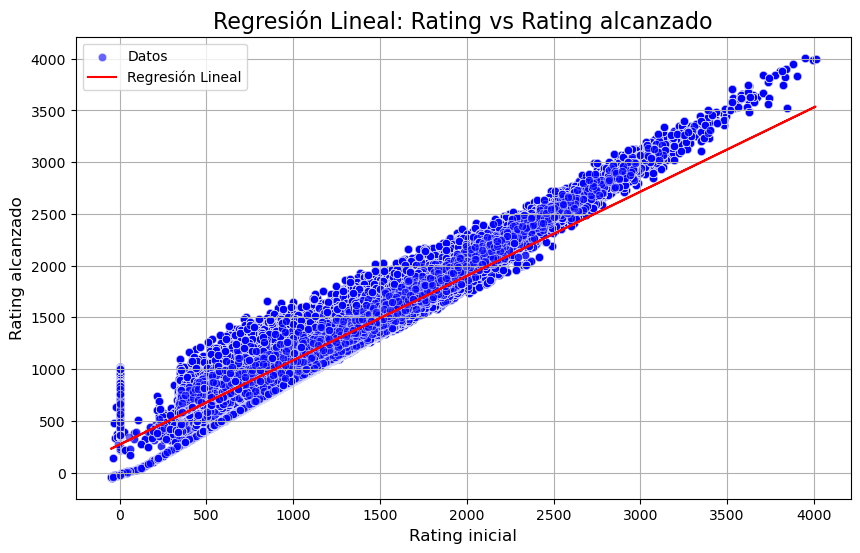

In [51]:
from sklearn.linear_model import LinearRegression

# Regresión lineal para rating vs rating_achieved
X = df_rating_clean[['old_rating']].dropna()  # Rating inicial
y = df_rating_clean['rating_achieved'].dropna()  # Rating alcanzado

# Ajustar modelo de regresión lineal
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)

# Gráfico
plt.figure(figsize=(10,6))
sns.scatterplot(x=X['old_rating'], y=y, color='blue', alpha=0.6, label='Datos')
plt.plot(X['old_rating'], y_pred, color='red', label='Regresión Lineal')
plt.title('Regresión Lineal: Rating vs Rating alcanzado', fontsize=16)
plt.xlabel('Rating inicial', fontsize=12)
plt.ylabel('Rating alcanzado', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


INTERPRETACION: Se observa que la línea tiene pendiente positiva lo cual significa que a mayor rating inicial, mayor rating alcanzado en promedio. Es decir, cuanto más cerca estén los puntos de la línea, más fuerte es la relación.